In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import keras
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import plot_importance
import optuna
import shap

: 

In [2]:
# For reproducibility add the same seed. "42" is the standard value.
random_number_seed = 42
np.random.seed(random_number_seed)
keras.utils.set_random_seed(random_number_seed)

#### Help functions

In [3]:
# Function that plots the training and validation for the different epochs.
from matplotlib import legend


def training_validation_history_plot(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")
    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].set_ylabel('Loss (MSE)', fontsize=16)
    # axes[0].set_title('Model Loss')
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    legend = axes[0].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    # MAE plot
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].set_ylabel('MAE', fontsize=16)
    # axes[1].set_title('Model MAE')
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    legend = axes[1].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    plt.tight_layout()
    plt.show() 

# Performance metrics on the training set
def performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred):
    mse_train  = mean_squared_error(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    r2_train   = r2_score(Y_train, Y_train_pred)
    
    print(f"\nPerformance metrics on the training set:")
    print(f"R² Score: {r2_train:.4f}")
    print(f"MSE:      {mse_train:.2f}")
    print(f"RMSE:     {rmse_train:.2f}%")
    print(f"MAE:      {mae_train:.2f}%")
    
    # Performance metrics on testing set
    mse_test  = mean_squared_error(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_test   = r2_score(Y_test, Y_test_pred)
    
    print(f"\nPerformance metrics on testing set:")
    print(f"R² Score: {r2_test:.4f}")
    print(f"MSE:      {mse_test:.2f}")
    print(f"RMSE:     {rmse_test:.2f}%")
    print(f"MAE:      {mae_test:.2f}%")

    return mse_train, rmse_train, mae_train, r2_train, mse_test, rmse_test, mae_test, r2_test

def parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    r2_test   = r2_score(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_train  = r2_score(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    
    # Test set parity plot
    axes[0].scatter(Y_test, Y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = -5
    max_val = 105
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[0].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    test_metrics_label = f'R² = {r2_test:.3f}\nRMSE = {rmse_test:.2f}%\nMAE = {mae_test:.2f}%'
    
    axes[0].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[0].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[0].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=test_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[0].set_xlim(-5, 105)
    axes[0].set_ylim(-5, 105)
    
    # Training set parity plot
    axes[1].scatter(Y_train, Y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = -5
    max_val = 105
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[1].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    train_metrics_label = f'R² = {r2_train:.3f}\nRMSE = {rmse_train:.2f}%\nMAE = {mae_train:.2f}%'
    
    axes[1].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[1].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[1].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=train_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[1].set_xlim(-5, 105)
    axes[1].set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

def residual_analysis(Y_test, Y_test_pred):

    residuals = Y_test - Y_test_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Residuals vs Predicted
    axes[0].scatter(Y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicted Yield (%)')
    axes[0].set_ylabel('Residual (Actual - Predicted) (%)')
    axes[0].set_title('Residuals vs Predicted Values')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of residuals
    axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Residuals\nMean = {residuals.mean():.2f}%, Std = {residuals.std():.2f}%')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def feature_importance(model):
    
    # Using the built in feature importance of Random Forests
    importance_df_rf = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df_rf['Feature'], importance_df_rf['Importance'])
    plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
    plt.title('Random Forest — Feature Importance')
    plt.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Top 10 most important features:")
    print(importance_df_rf.sort_values('Importance', ascending=False).head(10).to_string(index=False))

### Data preprocessing

##### Data Loading

In [ ]:
# Loading the Reizman data
full_data_path=  r"Reizman_database - MECH-ML-APPEND - FINAL"
df = pd.read_excel(full_data_path)

# Loading the ligand descriptor data from KRAKEN database
kraken_data_path = r"KRAKEN - Ligand descriptor database.xlsx"
df_kraken = pd.read_excel(kraken_data_path, sheet_name='dft_targets_SI')

In [70]:
all_descriptor_list = df_kraken.columns.tolist()
print(df_kraken.columns.tolist())

['ID', 'SMILES', 'vmin_vmin_boltz', 'vmin_r_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_eta_boltz', 'fmo_omega_boltz', 'somo_ra_boltz', 'somo_rc_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'spindens_P_ra_boltz', 'nbo_P_rc_boltz', 'spindens_P_rc_boltz', 'nmr_P_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'efg_amp_P_boltz', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'nuesp_P_boltz', 'E_solv_cds_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_e_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bds_occ_avg_boltz', 'E_solv_total_boltz', 'E_solv_elstat_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'fukui_p_boltz', 'fukui_m_boltz', 'vbur_vtot_boltz', 'vbur_ratio_vbur_vtot_boltz', 'Pint_P_int_boltz', 'Pint_dP_boltz', 'Pint_P_min_boltz', 'Pint_P_max_boltz', 'volume_boltz'

##### QM features extraction from KRAKEN database and appending to DataFrame

In [71]:
# This code is to append descriptors from the KRAKEN database to the DataFrame.
# Selected ligand descriptors
descriptor_list = [
    'vbur_vbur_min',
    'nbo_lp_P_e_boltz',
    'vbur_vtot_boltz',
    'sterimol_L_boltz', 
    'fmo_e_homo_boltz',
    'nuesp_P_boltz'
]

all_steric_descriptor_list = [
    'sphericity_boltz',
    'surface_area_boltz',
    'volume_boltz',
    'pyr_P_boltz',
    'pyr_alpha_boltz',
    'sterimol_burB1_boltz',
    'sterimol_burB5_boltz',
    'sterimol_burL_boltz',
    'sterimol_B1_boltz',
    'sterimol_B5_boltz',
    'sterimol_L_boltz',
    'vbur_vbur_boltz',
    'vbur_max_delta_qvbur_boltz',
    'vbur_ovbur_max_boltz',
    'vbur_ovtot_max_boltz',
    'vbur_qvbur_max_boltz',
    'vbur_qvtot_max_boltz',
    'vbur_max_delta_qvtot_boltz',
    'vbur_ovbur_min_boltz',
    'vbur_ovtot_min_boltz',
    'vbur_qvbur_min_boltz',
    'vbur_qvtot_min_boltz',
    'vbur_vtot_boltz',
    'vbur_ratio_vbur_vtot_boltz',
    'vbur_near_vbur_boltz',
    'vbur_near_vtot_boltz',
    'vbur_far_vbur_boltz',
    'vbur_far_vtot_boltz'
]

selected_ligand_descriptor_list = [
    'sphericity_boltz',
    'vbur_vbur_boltz',
    'sterimol_burB5_boltz',
    'fmo_eta_boltz',
    'fmo_omega_boltz',
    'fukui_m_boltz'
]

selected_aryl_descriptor_list = [
    'aryl_LUMO',
    'aryl_Electrophilicity',
    'aryl_HOMO-LUMO gap',
]

selected_boron_descriptor_list = [
    'boron_HOMO',
    'boron_Nucleofugality',
    'boron_Chem. potential'
]

selected_solvent_descriptor_list = [
    'solvent_Dipole module',
    'solvent_G solv. in H2O',
    'solvent_Polarizability'
]

def append_ligand_descriptors(df, df_kraken, descriptor_list):
    # Get all the unique ligand smiles from the database
    unique_ligand_smiles = df['ligand_smiles'].unique()

    # Create a DataFrame from the KRAKEN database where only the SMILES from the dataset are in there
    df_kraken_filtered = df_kraken[df_kraken['SMILES'].isin(unique_ligand_smiles)]

    # As can be seen, the XanthPhos is not recognized, because it is not in the KRAKEN database
    df_kraken_filtered.shape

    # Create a dictionary from the KRAKEN database with the SMILES and descriptors
    dict_kraken = {}
    for idx, row in df_kraken_filtered.iterrows():
        smiles = row['SMILES']
        dict_kraken[smiles] = {desc: row[desc] for desc in descriptor_list}

    print(f"KRAKEN database dictionary: {dict_kraken} \n")

    # Iterate through the database with reactions and add the descriptors as columns
    for idx, row in df.iterrows():
        smiles = row['ligand_smiles']

        if smiles in dict_kraken:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = dict_kraken[smiles][desc]
        else:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = None
            print(f"Warning: {smiles} not found in KRAKEN database")

def select_aryl_boron_solvent_descriptors(df, selected_aryl_list, selected_boron_list, selected_solvent_list):
    selected_descriptors = []
    for desc in selected_aryl_list:
        if desc in df.columns and desc.startswith('aryl_'):
            selected_descriptors.append(desc)
    for desc in selected_boron_list:
        if desc in df.columns and desc.startswith('boron_'):
            selected_descriptors.append(desc)
    for desc in selected_solvent_list:
        if desc in df.columns and desc.startswith('solvent_'):
            selected_descriptors.append(desc)

    # Remove other aryl_ and boron_ columns not in the selected lists
    all_aryl_boron_solvent_cols = [col for col in df.columns if col.startswith('aryl_') or col.startswith('boron_') or col.startswith('solvent_')]
    cols_to_drop = [col for col in all_aryl_boron_solvent_cols if col not in selected_descriptors]
    df.drop(columns=cols_to_drop, inplace=True)
    
    return selected_descriptors

# call the function with chosen ligand descriptors
append_ligand_descriptors(df, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.711352995999999, 'vbur_vbur_boltz': 107.8093841, 'sterimol_burB5_boltz': 7.238774196, 'fmo_eta_boltz': 0.197769897, 'fmo_omega_boltz': 0.03212394, 'fukui_m_boltz': 0.351437523}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_bol

### Feature engineering

##### Feature selection

In [72]:
# Additional data removal test
# df_remaining = df.sample(frac= 0.8, random_state = random_number_seed)
# df_removed = df.drop(df_remaining.index)

# Here, removed the datapoints with XanthPhos ligands as there are no descriptors for in the database.
df_remaining = df[df['ligand_smiles'] != '[H]P([H])c1cccc2c1Oc1ccccc1C2(C)C']

In [73]:
# Seperation of features (inputs) and targets (outputs) of the model
X = df_remaining.drop(['yield_pct', 'TON', 'case', 'experiment', 'number_aryl_halide',
                       'number_boron_species', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent',
                       # Added to see effect
                       'aryl_LUMO','aryl_Electrophilicity', 'aryl_HOMO-LUMO gap',
                       'boron_HOMO', 'boron_Nucleofugality', 'boron_Chem. potential',
                       'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz','ligand_sterimol_burB5_boltz',
                       'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz',
                       'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka',
                       ], axis = 1)
Y = df_remaining['yield_pct'].values

categorical_cols = ['name_aryl_halide', 'name_boron_species']
numerical_cols =  X.columns.tolist()
FEATURE_NAMES = X.columns.tolist()
print("Feature names:", FEATURE_NAMES)

print("Features shape:", X.shape)
print("Features:", X.columns.tolist())
print("Target shape:", Y.shape)

Feature names: ['time_s', 'temp_c', 'cat_loading', 'dG_OA', 'dG_TM', 'G_OA_TS', 'G_TM_TS', 'dG_boron_hydrolysis', 'G_Substrate', 'G_boron_species', 'k_OA', 'k_TM', 'dG_PdLArOH', 'G_precatalyst']
Features shape: (327, 14)
Features: ['time_s', 'temp_c', 'cat_loading', 'dG_OA', 'dG_TM', 'G_OA_TS', 'G_TM_TS', 'dG_boron_hydrolysis', 'G_Substrate', 'G_boron_species', 'k_OA', 'k_TM', 'dG_PdLArOH', 'G_precatalyst']
Target shape: (327,)


##### Train-test split

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Input features: {X_train.shape[1]}")

Training set size: 261 samples
Test set size: 66 samples
Input features: 14


In [75]:
# Here, remove the datapoints with P2-L1 catalyst, as these are the outliers and the model is not able to learn the difference for it.
# Have to make sure that this removal is done after train/test split, to make sure that the same datapoints go into the training as before and they are comparable.
# Find the indices of all P2-L1 datapoints in the original dataframe
p2l1_indices = df_remaining[df_remaining['catalyst'] == 'P2-L1'].index

print(f"Number of P2-L1 datapoints: {len(p2l1_indices)}")
print(f"  - in training set: {sum(X_train.index.isin(p2l1_indices))}")
print(f"  - in test set:     {sum(X_test.index.isin(p2l1_indices))}")

# Remove P2-L1 datapoints from training and test sets
train_mask = ~X_train.index.isin(p2l1_indices)
X_train_clean = X_train[train_mask]
Y_train_clean = Y_train[train_mask]

test_mask = ~X_test.index.isin(p2l1_indices)
X_test_clean  = X_test[test_mask]
Y_test_clean  = Y_test[test_mask]

print(f"Training set: {len(X_train)} → {len(X_train_clean)} samples")
print(f"Test set:     {len(X_test)}  → {len(X_test_clean)} samples")

Number of P2-L1 datapoints: 34
  - in training set: 26
  - in test set:     8
Training set: 261 → 235 samples
Test set:     66  → 58 samples


###  One run test - XGBoost architecture

Total training time: 0.13s

Performance metrics on the training set:
R² Score: 0.9975
MSE:      3.18
RMSE:     1.78%
MAE:      1.20%

Performance metrics on testing set:
R² Score: 0.8993
MSE:      125.76
RMSE:     11.21%
MAE:      7.84%
(3.1815454508755128, np.float64(1.7836887202860012), np.float64(1.199601281731179), 0.9975476650506724, 125.7586349858178, np.float64(11.214215754381481), np.float64(7.844753612893999), 0.899301028184419)


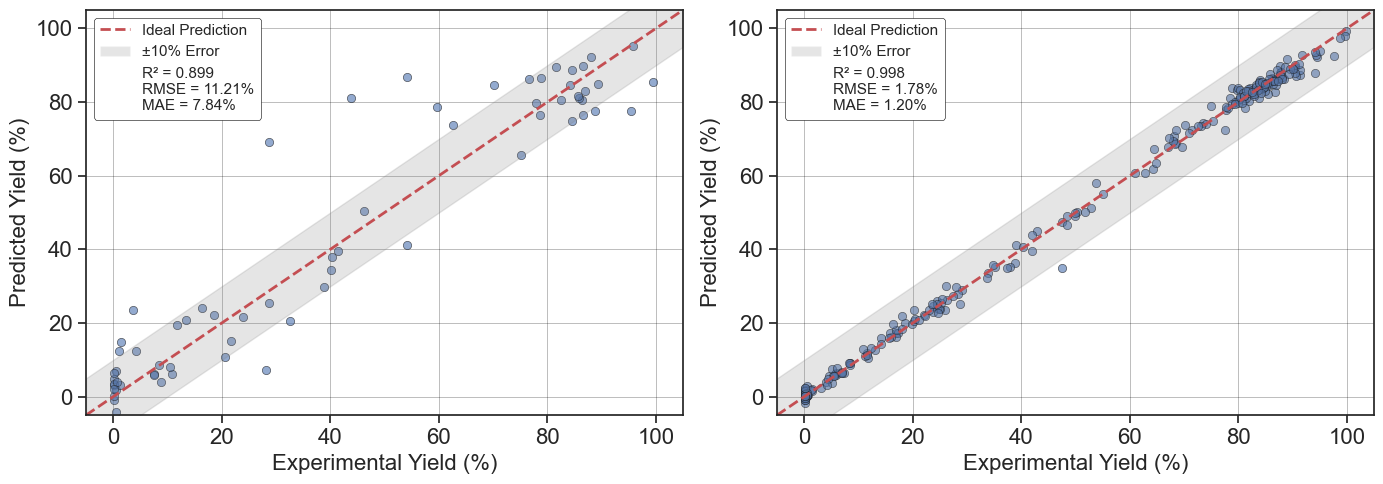

In [76]:
# XGBoost model architecture
def create_xgb_model(n_estimators=200, max_depth=4, learning_rate=0.1,
                     subsample=1.0, colsample_bytree=1.0, min_child_weight=1,
                     reg_alpha=0, reg_lambda=1, gamma=0, random_state=random_number_seed):
    model = XGBRegressor(
    n_estimators=n_estimators,       
    max_depth=max_depth,         
    learning_rate=learning_rate,         
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    min_child_weight=min_child_weight,
    reg_alpha=reg_alpha,
    reg_lambda=reg_lambda,
    gamma=gamma,
    random_state=random_state
    )

    return model

# Training the XGBoost model
start_training_time = time.time()
xgb_model = create_xgb_model()
xgb_model.fit(X_train, Y_train) # Here fit the model on X_train, because XGBoost can handle unscaled data and it is better to keep the original scale for tree-based models
end_training_time = time.time()
print(f"Total training time: {end_training_time - start_training_time:.2f}s")

# Predicting the yield
Y_train_pred_rf = xgb_model.predict(X_train)
Y_test_pred_rf  = xgb_model.predict(X_test)

# Performance metric. Model evaluation
print(performance_metrics(Y_train, Y_train_pred_rf, Y_test, Y_test_pred_rf))

# Executing the parity plot function
parity_plot(Y_train, Y_train_pred_rf, Y_test, Y_test_pred_rf)

<Axes: title={'center': 'XGBoost Feature Importance (Gain)'}, xlabel='Gain', ylabel='Features'>

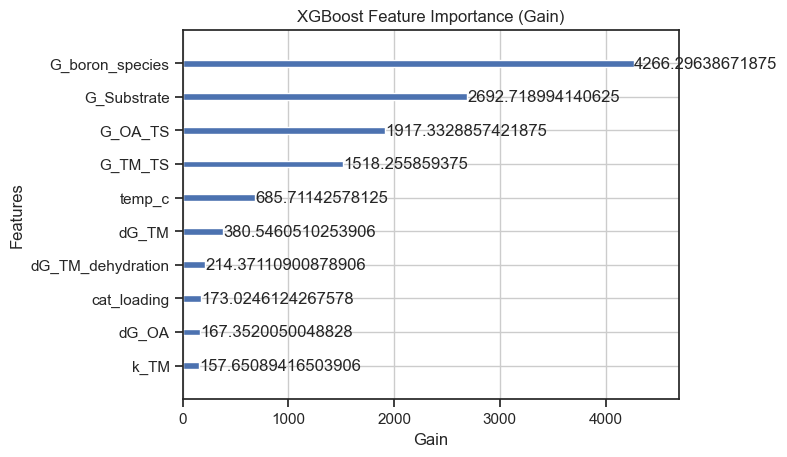

In [56]:
plot_importance(xgb_model, max_num_features=10, importance_type='gain', title='XGBoost Feature Importance (Gain)', xlabel='Gain', ylabel='Features')

#### Prediction without the P2-L1 included


Performance metrics on the training set:
R² Score: 0.9986
MSE:      1.83
RMSE:     1.35%
MAE:      0.88%

Performance metrics on testing set:
R² Score: 0.9548
MSE:      57.79
RMSE:     7.60%
MAE:      5.99%


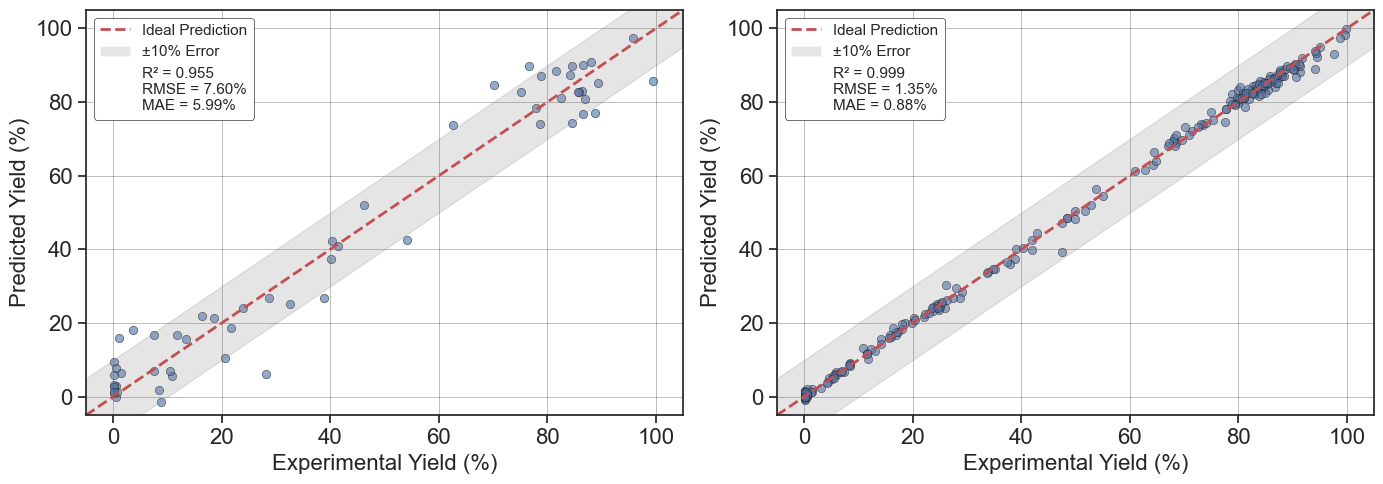

In [77]:
# Refit the model on the cleaned training set
xgb_model.fit(X_train_clean, Y_train_clean)

# Predict
Y_train_pred_clean = xgb_model.predict(X_train_clean)
Y_test_pred_clean  = xgb_model.predict(X_test_clean)

# Metrics and parity plot
performance_metrics(Y_train_clean, Y_train_pred_clean, Y_test_clean, Y_test_pred_clean)
parity_plot(Y_train_clean, Y_train_pred_clean, Y_test_clean, Y_test_pred_clean)

### Final model - Hyperparameter optimization using Optuna

In [58]:
# Defining the objective function
def objective(trial):
    # Defining the parameter range over which the optimization is performed. Int are continuous, and categorical not
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',      100, 1000),
        'max_depth'        : trial.suggest_int  ('max_depth',           3,   6),
        'learning_rate'    : trial.suggest_float('learning_rate',     1e-3,  0.3, log=True),
        'subsample'        : trial.suggest_float('subsample',          0.5,  1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree',   0.5,  1.0),
        'min_child_weight' : trial.suggest_int  ('min_child_weight',    1,   10),
        'reg_alpha'        : trial.suggest_float('reg_alpha',          1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',         1e-8, 10.0, log=True),
        'gamma'            : trial.suggest_float('gamma',              1e-8,  2.0, log=True),
        'random_state'     : random_number_seed,
        'tree_method'      : 'hist',
        'verbosity'        : 0,
    }

    model = XGBRegressor(**params, n_jobs=1)

    # Here take the neg RMSE, take negative of scores and then minimize the study. Because cross_val_score thinks higher is better
    scores = cross_val_score(model, X_train_clean, Y_train_clean, cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1        # Use all cores
    )
    return -scores.mean()

In [59]:
# Running the optimization study
start_xgb_optuna = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=random_number_seed))
study.optimize(objective, n_trials=200, show_progress_bar=True)
best_params = study.best_params
end_xgb_optuna = time.time()

# Printing the results
print(f"\nOptuna search completed in {(end_xgb_optuna - start_xgb_optuna)/60:.1f} minutes")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best parameters: {study.best_params}")
print(f"Best CV RMSE: {study.best_value:.4f}")

[I 2026-05-29 17:06:56,040] A new study created in memory with name: no-name-2c8cced2-8dda-4bb5-b6c7-4a5719be394c


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-05-29 17:07:03,583] Trial 0 finished with value: 9.907183506571721 and parameters: {'n_estimators': 437, 'max_depth': 6, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 0.0009769531630295122}. Best is trial 0 with value: 9.907183506571721.
[I 2026-05-29 17:07:07,086] Trial 1 finished with value: 10.6135251773669 and parameters: {'n_estimators': 737, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'gamma': 0.00022699635282715677}. Best is trial 0 with value: 9.907183506571721.
[I 2026-05-29 17:07:15,165] Trial 2 finished with value: 10.67569692818626 and parameters: {'n_estimators': 489, 'max_depth': 4, 'learning_rate': 0.032781876533976156, 's

In [ ]:
# import joblib
# # Save the Optuna study
# joblib.dump(study, "MECH-ML-XGB-IMPROVED-FINAL.pkl")

['MECH-ML-XGB-IMPROVED-FINAL.pkl']

In [17]:
optuna.visualization.plot_parallel_coordinate(study)

In [18]:
optuna.visualization.plot_param_importances(study)

In [ ]:
optuna.visualization.plot_optimization_history(study)

### Final model - Evaluation on Optuna model

In [78]:
def run_cross_validation_xgb(X, Y, params, n_splits=5, random_state=random_number_seed):
                             

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Making empty list for performance metrics
    mae_per_fold_test  = []
    mae_per_fold_train = []
    r2_per_fold_test   = []
    r2_per_fold_train  = []

    # Iterating over the amount of folds and thus also the training and test folds for each
    for fold_no, (train_idx, test_idx) in enumerate(cv.split(X, Y), start=1):
        print(f'Training for fold {fold_no}/{n_splits}')

        # Split data
        train_X = X.iloc[train_idx]
        test_X  = X.iloc[test_idx]
        train_Y = Y[train_idx]
        test_Y  = Y[test_idx]

        # Preprocessing inside each loop to avoid data leakage. Also no target (Y) scaler needed here
        # fold_preprocessor =ColumnTransformer(
        # transformers=[
        #     ('num', StandardScaler(), numerical_cols)
        # ])
        # train_X_transformed = fold_preprocessor.fit_transform(train_X)
        # test_X_transformed  = fold_preprocessor.transform(test_X)

        # Create XGBoost model
        fold_xgb = XGBRegressor(**params, random_state=random_number_seed,
                                 tree_method='hist', verbosity=0           
        )
        # Train XGBoost model
        fold_xgb.fit(train_X, train_Y)

        # Predictions
        test_predictions  = fold_xgb.predict(test_X)
        train_predictions = fold_xgb.predict(train_X)

        # Metrics
        mae_test  = np.mean(np.abs(test_predictions - test_Y))
        mae_train = np.mean(np.abs(train_predictions - train_Y))
        r2_test   = r2_score(test_Y, test_predictions)
        r2_train  = r2_score(train_Y, train_predictions)

        mae_per_fold_test.append(mae_test)
        mae_per_fold_train.append(mae_train)
        r2_per_fold_test.append(r2_test)
        r2_per_fold_train.append(r2_train)

        print(f"Test  R² = {r2_test:.3f}  |  MAE = {mae_test:.2f}%")
        print(f"Train R² = {r2_train:.3f}  |  MAE = {mae_train:.2f}%")

        # Parity plots per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, actual, predicted, split_label, r2_val, mae_val in [
            (axes[0], test_Y,  test_predictions,  'Test',  r2_test,  mae_test),
            (axes[1], train_Y, train_predictions, 'Train', r2_train, mae_train),
        ]:
            ax.scatter(actual, predicted, alpha=0.6, edgecolors='black', linewidth=0.5)
            lo, hi = min(actual.min(), predicted.min()), max(actual.max(), predicted.max())
            ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
            ax.set_xlabel('Experimental Yield (%)', fontsize=12)
            ax.set_ylabel('Predicted Yield (%)',    fontsize=12)
            ax.set_title(
                f'Parity Plot – {split_label} Set  |  Fold {fold_no}\n'
                f'R² = {r2_val:.3f},  MAE = {mae_val:.2f}%', fontsize=12
            )
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-10, 110)
            ax.set_ylim(-10, 110)

        plt.tight_layout()
        plt.show()

    return r2_per_fold_test, r2_per_fold_train, mae_per_fold_test, mae_per_fold_train


Performance metrics on the training set:
R² Score: 0.9973
MSE:      3.49
RMSE:     1.87%
MAE:      1.34%

Performance metrics on testing set:
R² Score: 0.9615
MSE:      49.18
RMSE:     7.01%
MAE:      5.40%
Parity plot for the final model - performance on the held out test set


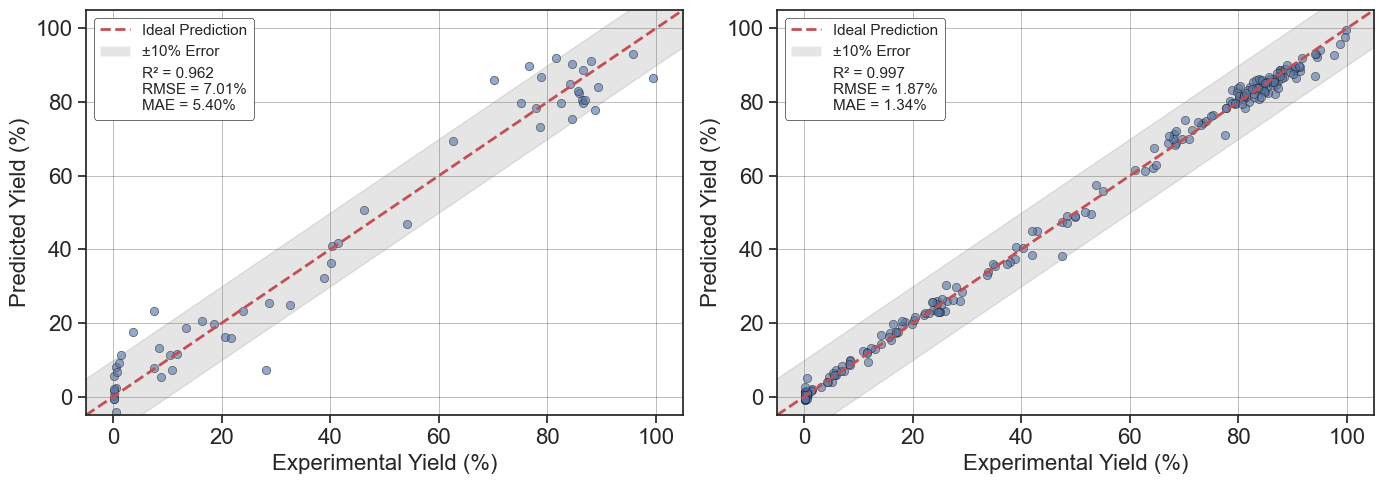

Training for fold 1/5
Test  R² = 0.961  |  MAE = 5.89%
Train R² = 0.998  |  MAE = 1.21%


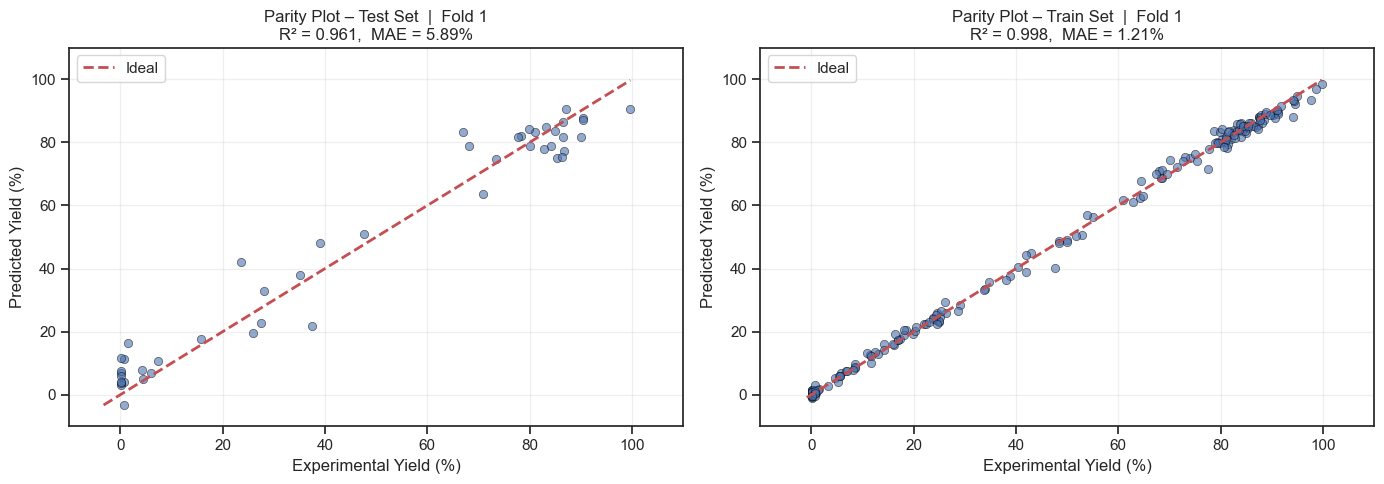

Training for fold 2/5
Test  R² = 0.820  |  MAE = 10.03%
Train R² = 0.999  |  MAE = 0.96%


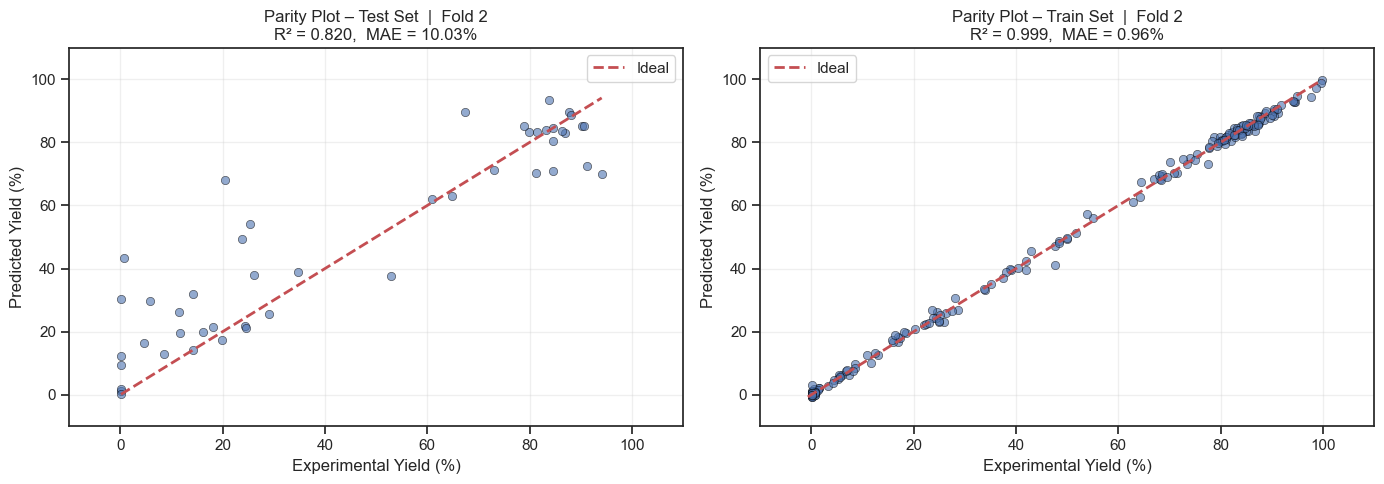

Training for fold 3/5
Test  R² = 0.917  |  MAE = 6.71%
Train R² = 0.998  |  MAE = 1.18%


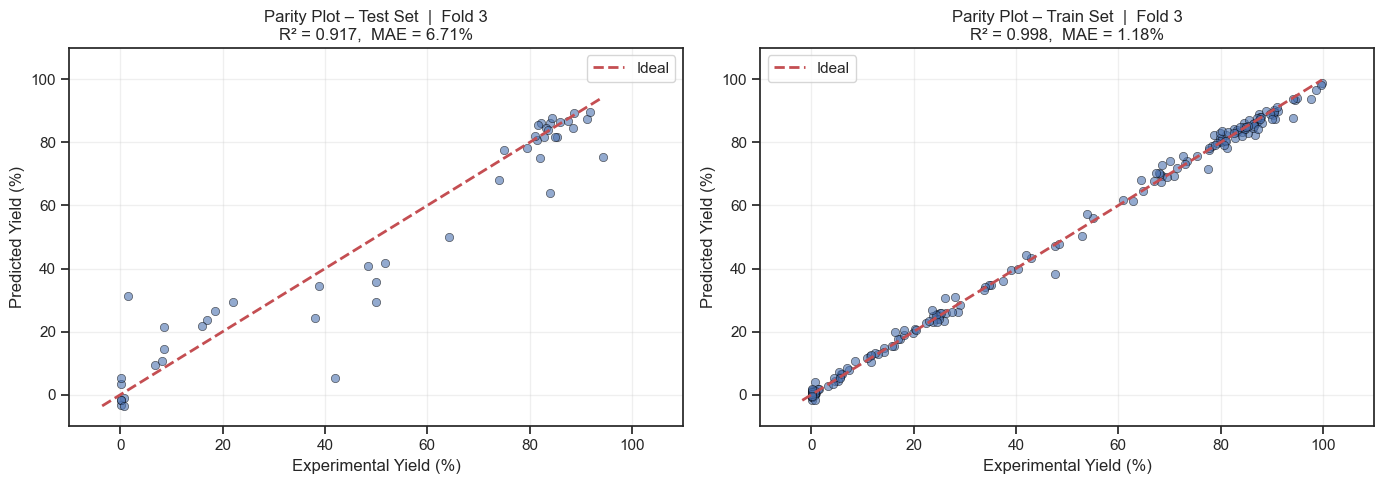

Training for fold 4/5
Test  R² = 0.924  |  MAE = 7.49%
Train R² = 0.998  |  MAE = 1.08%


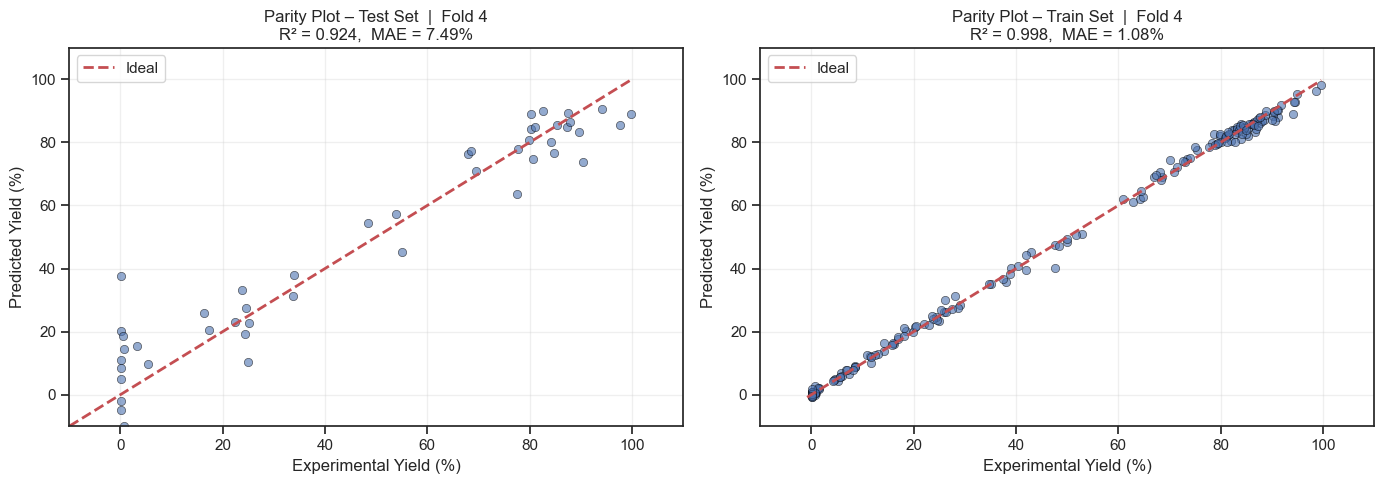

Training for fold 5/5
Test  R² = 0.912  |  MAE = 7.19%
Train R² = 0.998  |  MAE = 1.06%


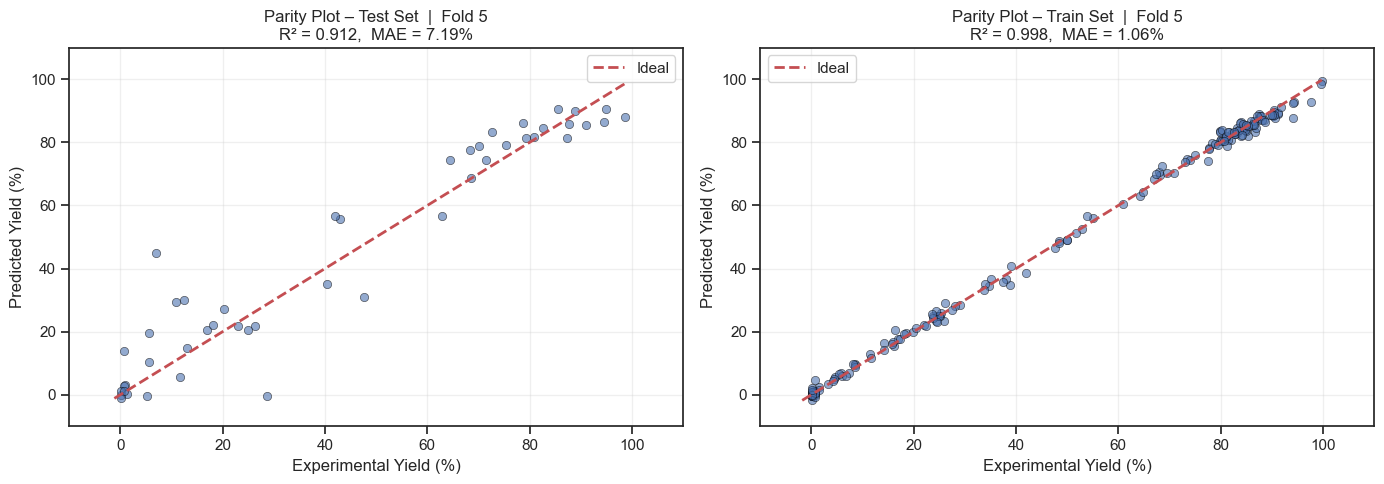


Cross-validation results testing:
MAE: 7.46% ± 1.39%
R²:  0.907 ± 0.04663

Cross-validation results training:
MAE: 1.10% ± 0.09%
R²:  0.998 ± 0.00038


In [79]:
# Making the model
xgb_best_model = XGBRegressor(random_state=random_number_seed, tree_method='hist',
                              verbosity=0, **study.best_params, n_jobs=-1
                               )
# Training the model
xgb_best_model.fit(X_train_clean, Y_train_clean)

# Calculating the target
Y_train_xgb_best_model_pred = xgb_best_model.predict(X_train_clean)
Y_test_xgb_best_model_pred  = xgb_best_model.predict(X_test_clean)

# Metrics and plotting
performance_metrics(Y_train_clean, Y_train_xgb_best_model_pred, Y_test_clean, Y_test_xgb_best_model_pred)
print("Parity plot for the final model - performance on the held out test set")
parity_plot(Y_train_clean, Y_train_xgb_best_model_pred, Y_test_clean, Y_test_xgb_best_model_pred)

# Run cross validation on final model
r2_per_fold_test_xgb, r2_per_fold_train_xgb, mae_per_fold_test_xgb, mae_per_fold_train_xgb = run_cross_validation_xgb(X_train_clean, Y_train_clean, params=study.best_params, n_splits=5, )

# Summary
print(f'\nCross-validation results testing:')
print(f'MAE: {np.mean(mae_per_fold_test_xgb):.2f}% ± {np.std(mae_per_fold_test_xgb):.2f}%')
print(f'R²:  {np.mean(r2_per_fold_test_xgb):.3f} ± {np.std(r2_per_fold_test_xgb):.5f}')

print(f'\nCross-validation results training:')
print(f'MAE: {np.mean(mae_per_fold_train_xgb):.2f}% ± {np.std(mae_per_fold_train_xgb):.2f}%')
print(f'R²:  {np.mean(r2_per_fold_train_xgb):.3f} ± {np.std(r2_per_fold_train_xgb):.5f}')

In [ ]:
# import joblib
# joblib.dump(xgb_best_model, "xgb_suzuki_model_MECH_TEST.pkl")
# joblib.dump(FEATURE_NAMES,  "xgb_feature_names_MECH_TEST.pkl")
# joblib.dump(X_train_clean, "MECH-ML-XGB-XTRAIN-FINAL.pkl")

['MECH-ML-XGB-XTRAIN-FINAL.pkl']

<Axes: title={'center': 'XGBoost Feature Importance (Gain)'}, xlabel='Gain', ylabel='Features'>

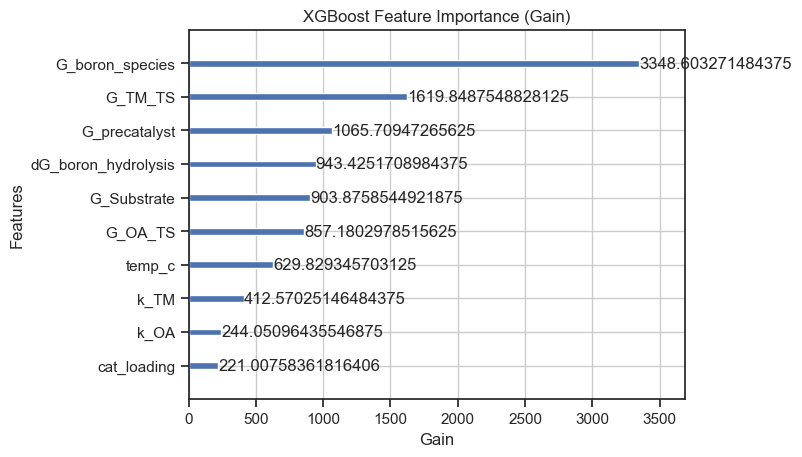

In [81]:
plot_importance(xgb_best_model, max_num_features=10, importance_type='gain', title='XGBoost Feature Importance (Gain)', xlabel='Gain', ylabel='Features')

#### SHAP-analysis of the Optuna best model

In [82]:
import xgboost, shap
# Make sure that the XGBoost version is 2.0.3 (or similar), but not the newest version as this gives compatability issues with SHAP.
print(f"XGBoost version: {xgboost.__version__}")
print(f"SHAP version:    {shap.__version__}")

XGBoost version: 2.0.3
SHAP version:    0.48.0


In [83]:
# Don't need a background dataset for tree-based models, so we can directly compute SHAP values on the test set
explainer = shap.TreeExplainer(xgb_best_model)
shap_values_raw = explainer.shap_values(X_test)

# Handle both old SHAP (returns list) and new SHAP (returns array directly)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[0]   # old: list of arrays, one per output
else:
    shap_vals = shap_values_raw      # new: array directly, shape (n_samples, n_features)

# Squeeze in case of shape (n_samples, n_features, 1)
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")         # should be (n_test, n_features)
print(f"X_test shape: {X_test.shape}")  # should match

SHAP values shape: (66, 14)
X_test shape: (66, 14)


C:\Users\livio\AppData\Local\Temp\ipykernel_22700\4024603241.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, plot_type='bar', show=True)


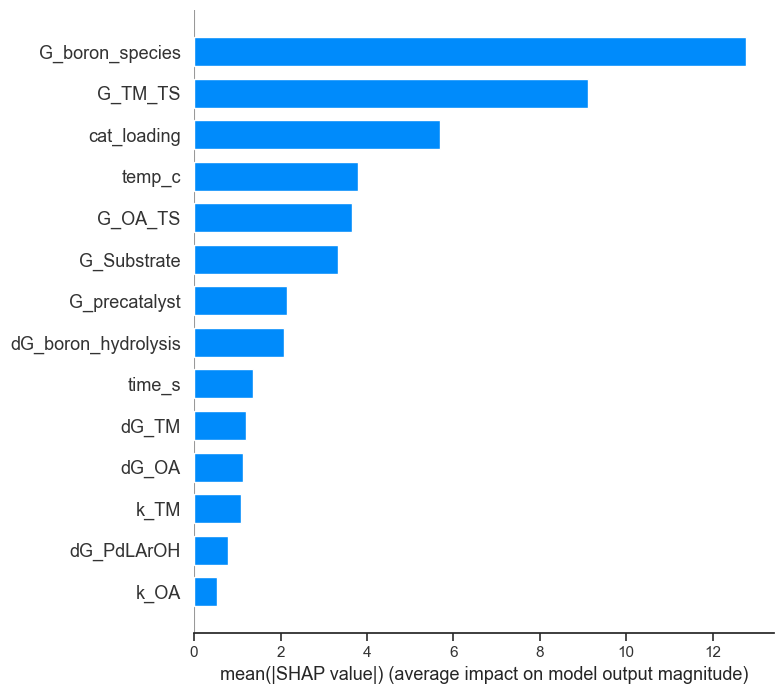

In [84]:
shap.summary_plot(shap_vals, X_test, plot_type='bar', show=True)

C:\Users\livio\AppData\Local\Temp\ipykernel_22700\4081524001.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, show=True)


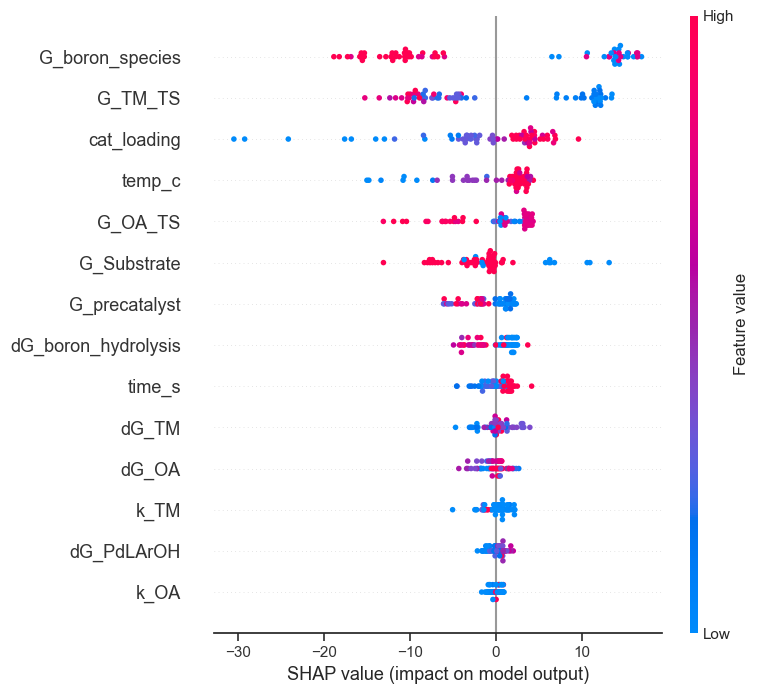

In [85]:
# Beeswarm plot
shap.summary_plot(shap_vals, X_test, show=True)

### Outlier analysis

In [94]:
results_check = pd.DataFrame({
    'y_true': Y_test,
    'y_pred': Y_test_xgb_best_model_pred,
    'residual': Y_test - Y_test_xgb_best_model_pred,
    'abs_residual': np.abs(Y_test - Y_test_xgb_best_model_pred),
    'ligand' : df_remaining['catalyst'],
    'time': df_remaining['time_s'],
    'temperautre': df_remaining['temp_c'],
    'cat loading': df_remaining['cat_loading'],
    'aryl halide': df_remaining['name_aryl_halide'],
    'boron species': df_remaining['name_boron_species']
}, index=X_test.index)

# Find outliers
outliers = results_check.nlargest(10, 'abs_residual')
# # Look them up in the orginal dataframe
# original_df.loc[outliers.index]

In [95]:
import plotly.express as px
import plotly.graph_objects as go

results_check['original_index'] = results_check.index
fig = px.scatter(results_check, x='y_true', y='y_pred', hover_data=['original_index', 'residual'], title='Predicted vs Actual Yields with Residuals')
fig.add_shape(type='line', x0=0, y0=0, x1=100, y1=100, line=dict(color='Red', dash='dash'))
fig.show()

print(outliers)

     y_true     y_pred   residual  abs_residual ligand   time  temperautre  \
298    28.7  74.795448 -46.095448     46.095448  P2-L1  150.3         71.6   
211    43.9  82.216507 -38.316507     38.316507  P2-L1   60.0        110.0   
358    54.2  92.441559 -38.241559     38.241559  P1-L1   60.0        110.0   
279    95.5  66.533859  28.966141     28.966141  P2-L1  600.0         65.3   
81     75.2  51.129627  24.070373     24.070373  P1-L7   94.8        110.0   
119    28.1   7.140616  20.959384     20.959384  P1-L7  149.0        110.0   
208    59.7  78.160530 -18.460530     18.460530  P2-L1  160.9        110.0   
348    99.5  84.395988  15.104012     15.104012  P1-L2  276.4         69.3   
51     41.4  27.261330  14.138670     14.138670  P1-L1  600.0        110.0   
150     1.1  14.819920 -13.719920     13.719920  P1-L2  600.0         39.8   

     cat loading       aryl halide  \
298        1.037  2-chloropyridine   
211        1.413  3-chloropyridine   
358        0.977  2-chlorop

In [191]:
results_check['original_index'] = results_check.index
outlier_indices = outliers.index

fig = px.scatter(
    results_check,
    x='y_true',
    y='y_pred',
    color='ligand',                  # <-- color by ligand
    hover_data={
        'original_index': True,
        'residual': ':.2f',
        'ligand': True,
        'aryl halide': True,
        'boron species': True,
        'time': True,
        'temperautre': True,
        'cat loading': True,
    },
    title='Predicted vs Actual Yields — colored by ligand',
    opacity=0.7,
)

# Add dashed perfect-prediction line
fig.add_shape(
    type='line', x0=0, y0=0, x1=100, y1=100,
    line=dict(color='black', dash='dash', width=1)
)

# Overlay outlier ring markers
outlier_data = results_check.loc[outlier_indices]
fig.add_trace(go.Scatter(
    x=outlier_data['y_true'],
    y=outlier_data['y_pred'],
    mode='markers+text',
    marker=dict(size=18, color='rgba(0,0,0,0)', line=dict(color='red', width=2)),
    text=outlier_data.index.astype(str),
    textposition='top center',
    textfont=dict(size=10, color='red'),
    name='Top 10 outliers',
    hoverinfo='skip',               # avoids double tooltip
))

fig.update_layout(
    xaxis_title='Actual yield (%)',
    yaxis_title='Predicted yield (%)',
    legend_title='Ligand',
    width=800, height=600,
)
fig.show()